# 🧬 Embryo Viability Classification — ResNet18 Fine-Tuning

**Dataset:** `viable` / `non_viable` embryo images (512×384 px)  
**Architecture:** ResNet18 (pretrained ImageNet, progressive fine-tuning)  
**Features:** Weighted sampler, early stopping, Grad-CAM, resume from checkpoint  

---
### ✅ Before running
1. Runtime → Change runtime type → **T4 GPU**
2. Mount Drive in Cell 2
3. Run cells top to bottom

In [ ]:
import shutil
if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)
    print('Old split deleted — will recreate with new ratios.')

Old split deleted — will recreate with new ratios.


In [ ]:
!pip install -q torchvision matplotlib scikit-learn seaborn tqdm grad-cam

import os, json, time, copy, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 41.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using device: cuda
  GPU : Tesla T4
  VRAM: 15.6 GB


## 🔗 Cell 2 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted.')

Mounted at /content/drive
Google Drive mounted.


## ⚙️ Cell 3 — Configuration (edit here)

In [ ]:
# ── Paths ────────────────────────────────────────────────────────────────────
DATA_DIR       = '/content/drive/MyDrive/embryo_dataset_looklike/labelled_embryos/fine_tuned_labeled'
CHECKPOINT_DIR = '/content/drive/MyDrive/Resnet18_fies/embryo_checkpoints'
LOG_DIR        = '/content/drive/MyDrive/Resnet18_fies/embryo_logs'

# ── Image config ──────────────────────────────────────────────────────────
RESIZE_TO  = (400, 400)
CROP_SIZE  = 384

# ── Hyperparameters ───────────────────────────────────────────────────────
BATCH_SIZE     = 8
NUM_EPOCHS     = 50
LR_HEAD        = 3e-4
LR_FEATURE     = 1e-5    # very gentle backbone LR
WEIGHT_DECAY   = 1e-3
PATIENCE       = 12
UNFREEZE_EPOCH = 15      # keep backbone frozen much longer
TRAIN_SPLIT    = 0.80
VAL_SPLIT      = 0.15    # test = 0.05




# ── Resume training (set to .pth path or leave None) ─────────────────────────
RESUME_CHECKPOINT = None
# RESUME_CHECKPOINT = '/content/drive/MyDrive/embryo_checkpoints/best_model.pth'

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
CLASS_NAMES = ['non_viable', 'viable']

print('Config summary:')
print(f'  DATA_DIR       : {DATA_DIR}')
print(f'  CHECKPOINT_DIR : {CHECKPOINT_DIR}')
print(f'  Crop size      : {CROP_SIZE}x{CROP_SIZE}')
print(f'  Batch size     : {BATCH_SIZE}')
print(f'  Epochs         : {NUM_EPOCHS}')
print(f'  Resume         : {RESUME_CHECKPOINT}')

Config summary:
  DATA_DIR       : /content/drive/MyDrive/embryo_dataset_looklike/labelled_embryos/fine_tuned_labeled
  CHECKPOINT_DIR : /content/drive/MyDrive/Resnet18_fies/embryo_checkpoints
  Crop size      : 384x384
  Batch size     : 8
  Epochs         : 50
  Resume         : None


## 🗂️ Cell 4 — Dataset Inspection

viable     : 234 images
non_viable : 520 images
total      : 754 images


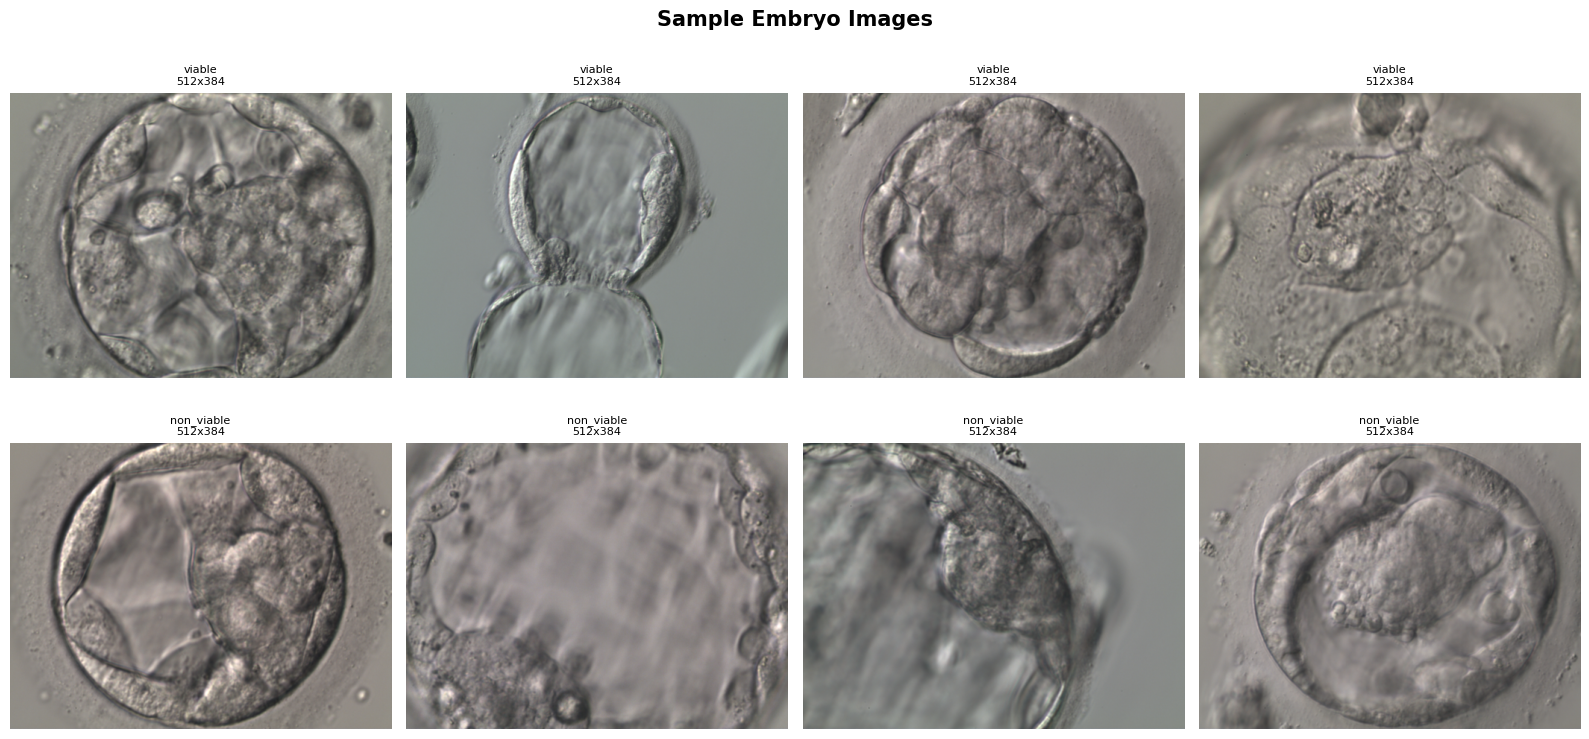

In [ ]:
data_path = Path(DATA_DIR)
assert data_path.exists(), f'DATA_DIR not found: {DATA_DIR}'

viable_imgs    = list((data_path / 'viable').glob('*.*'))
nonviable_imgs = list((data_path / 'non_viable').glob('*.*'))

print(f'viable     : {len(viable_imgs)} images')
print(f'non_viable : {len(nonviable_imgs)} images')
print(f'total      : {len(viable_imgs) + len(nonviable_imgs)} images')

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Embryo Images', fontsize=15, fontweight='bold')
for row, (cls, imgs) in enumerate([('viable', viable_imgs), ('non_viable', nonviable_imgs)]):
    samples = random.sample(imgs, min(4, len(imgs)))
    for col, p in enumerate(samples):
        img = Image.open(p).convert('RGB')
        axes[row][col].imshow(img)
        axes[row][col].set_title(f'{cls}\n{img.size[0]}x{img.size[1]}', fontsize=8)
        axes[row][col].axis('off')
plt.tight_layout(); plt.show()

## 🔀 Cell 5 — Train / Val / Test Split

In [ ]:
import shutil
from sklearn.model_selection import train_test_split

SPLIT_DIR = Path('/content/drive/MyDrive/Resnet18_fies/embryo_split')

if not SPLIT_DIR.exists():
    print('Creating split folders...')
    for split in ['train', 'val', 'test']:
        for cls in CLASS_NAMES:
            (SPLIT_DIR / split / cls).mkdir(parents=True, exist_ok=True)

    def do_split(imgs, cls_name):
        tr, tmp = train_test_split(imgs, test_size=(1 - TRAIN_SPLIT), random_state=SEED)
        vf = VAL_SPLIT / (1 - TRAIN_SPLIT)
        vl, te = train_test_split(tmp, test_size=(1 - vf), random_state=SEED)
        for subset, files in [('train', tr), ('val', vl), ('test', te)]:
            for f in files:
                shutil.copy(f, SPLIT_DIR / subset / cls_name / Path(f).name)
        return len(tr), len(vl), len(te)

    for cls, imgs in [('viable', viable_imgs), ('non_viable', nonviable_imgs)]:
        tr, vl, te = do_split(imgs, cls)
        print(f'  {cls:12s}  train={tr}  val={vl}  test={te}')
else:
    print('Split already exists, reusing.')

for sp in ['train', 'val', 'test']:
    counts = {c: len(list((SPLIT_DIR/sp/c).glob('*'))) for c in CLASS_NAMES}
    print(f'{sp:6s}: {counts}')

Creating split folders...
  viable        train=187  val=35  test=12
  non_viable    train=416  val=78  test=26
train : {'non_viable': 416, 'viable': 187}
val   : {'non_viable': 78, 'viable': 35}
test  : {'non_viable': 26, 'viable': 12}


## 🔄 Cell 6 — Transforms & DataLoaders

In [ ]:
viable_imgs    = list((data_path / 'viable').glob('*.*'))
nonviable_imgs = list((data_path / 'non_viable').glob('*.*'))
print(f'viable     : {len(viable_imgs)}')
print(f'non_viable : {len(nonviable_imgs)}')

viable     : 234
non_viable : 520


In [ ]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(RESIZE_TO),
    transforms.RandomCrop(CROP_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])



val_test_transform = transforms.Compose([
    transforms.Resize(RESIZE_TO),
    transforms.CenterCrop(CROP_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_ds = datasets.ImageFolder(SPLIT_DIR / 'train', transform=train_transform)
val_ds   = datasets.ImageFolder(SPLIT_DIR / 'val',   transform=val_test_transform)
test_ds  = datasets.ImageFolder(SPLIT_DIR / 'test',  transform=val_test_transform)
print(f'Class -> index: {train_ds.class_to_idx}')

# Weighted sampler for class imbalance
targets      = [s[1] for s in train_ds.samples]
class_counts = np.bincount(targets)

# Oversample viable (minority) to exactly match non_viable count
class_weights  = 1.0 / class_counts
sample_weights = [class_weights[t] for t in targets]
sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=int(class_counts.max()) * len(CLASS_NAMES),  # balanced epoch size
    replacement=True
)



train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Batches -> train:{len(train_loader)}  val:{len(val_loader)}  test:{len(test_loader)}')

Class -> index: {'non_viable': 0, 'viable': 1}
Batches -> train:104  val:15  test:5


## 🏗️ Cell 7 — Build ResNet18 Model

In [ ]:
def build_resnet18(num_classes=2, freeze_backbone=True):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False
    in_f = model.fc.in_features  # 512
    model.fc = nn.Sequential(
        nn.Linear(in_f, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.5),        # increased from 0.4
        nn.Linear(256, 64),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),        # second dropout layer
        nn.Linear(64, num_classes),
    )
    return model

model = build_resnet18(num_classes=2, freeze_backbone=True).to(DEVICE)

dummy = torch.randn(2, 3, CROP_SIZE, CROP_SIZE).to(DEVICE)
out   = model(dummy)
print(f'Forward pass OK — output shape: {out.shape}')
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total:,}')
print(f'Trainable params: {trainable:,}  (head only — backbone frozen)')

Forward pass OK — output shape: torch.Size([2, 2])
Total params    : 11,324,930
Trainable params: 148,418  (head only — backbone frozen)


## 🔁 Cell 8 — Resume from Checkpoint (optional)

In [ ]:
START_EPOCH  = 0
best_val_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

if RESUME_CHECKPOINT and os.path.isfile(RESUME_CHECKPOINT):
    ckpt = torch.load(RESUME_CHECKPOINT, map_location=DEVICE)
    for p in model.parameters():  # unfreeze all before loading
        p.requires_grad = True
    model.load_state_dict(ckpt['model_state_dict'])
    START_EPOCH  = ckpt.get('epoch', 0) + 1
    best_val_acc = ckpt.get('best_val_acc', 0.0)
    history      = ckpt.get('history', history)
    print(f'Resumed from: {RESUME_CHECKPOINT}')
    print(f'Continuing from epoch {START_EPOCH}, best val acc = {best_val_acc:.4f}')
else:
    print('No checkpoint — starting from scratch.')

No checkpoint — starting from scratch.


## 🎯 Cell 9 — Loss, Optimiser & Scheduler

In [ ]:


# Weight viable class 2.2x higher in loss
cw = torch.tensor([1.0, 2.2], dtype=torch.float).to(DEVICE)  # [non_viable, viable]
loss_weights = (cw.sum() / (len(CLASS_NAMES) * cw)).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=cw)
# criterion = nn.CrossEntropyLoss(weight=loss_weights)
print(f'Loss weights (non_viable, viable): {loss_weights.cpu().numpy()}')



def make_optimizer(model, unfreeze_backbone=False):
    head_ids = {id(p) for p in model.fc.parameters()}
    backbone_params = [p for p in model.parameters() if id(p) not in head_ids]
    groups = [{'params': list(model.fc.parameters()), 'lr': LR_HEAD}]
    if unfreeze_backbone:
        groups.insert(0, {'params': backbone_params, 'lr': LR_FEATURE})
    return optim.AdamW(groups, weight_decay=WEIGHT_DECAY)

optimizer = make_optimizer(model, unfreeze_backbone=(RESUME_CHECKPOINT is not None))
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
print('Optimiser and scheduler ready.')

Loss weights (non_viable, viable): [1.6        0.72727275]
Optimiser and scheduler ready.


## 🚀 Cell 10 — Training Loop

In [ ]:
def run_epoch(model, loader, criterion, optimizer=None, phase='train'):
    is_train = phase == 'train'
    model.train() if is_train else model.eval()
    running_loss = correct = total = 0
    with torch.set_grad_enabled(is_train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if is_train:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            if is_train:
                loss.backward()
                optimizer.step()
            running_loss += loss.item() * imgs.size(0)
            preds   = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += imgs.size(0)
    return running_loss / total, correct / total


patience_counter  = 0
backbone_unfrozen = (RESUME_CHECKPOINT is not None)
best_model_wts    = copy.deepcopy(model.state_dict())

print(f'Training epochs {START_EPOCH+1} to {NUM_EPOCHS}')
print('=' * 70)

for epoch in range(START_EPOCH, NUM_EPOCHS):
    t0 = time.time()

    # Progressive unfreezing
    if not backbone_unfrozen and epoch >= UNFREEZE_EPOCH:
        print(f'Epoch {epoch+1}: Unfreezing backbone...')
        for p in model.parameters():
            p.requires_grad = True
        optimizer = make_optimizer(model, unfreeze_backbone=True)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=NUM_EPOCHS - epoch, eta_min=1e-6)
        backbone_unfrozen = True

    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, 'train')
    vl_loss, vl_acc = run_epoch(model, val_loader,   criterion, None,      'val')
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    print(f'Epoch [{epoch+1:03d}/{NUM_EPOCHS}] '
          f'Train loss={tr_loss:.4f} acc={tr_acc:.4f} | '
          f'Val loss={vl_loss:.4f} acc={vl_acc:.4f} | '
          f'{time.time()-t0:.1f}s')

    if vl_acc > best_val_acc:
        best_val_acc   = vl_acc
        patience_counter = 0
        best_model_wts = copy.deepcopy(model.state_dict())
        ckpt_path = os.path.join(CHECKPOINT_DIR, 'best_model.pth')
        torch.save({
            'epoch': epoch, 'model_state_dict': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'best_val_acc': best_val_acc, 'history': history,
            'class_to_idx': train_ds.class_to_idx, 'crop_size': CROP_SIZE,
        }, ckpt_path)
        print(f'  -> Best model saved (val_acc={best_val_acc:.4f})')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

    if (epoch + 1) % 5 == 0:
        p = os.path.join(CHECKPOINT_DIR, f'epoch_{epoch+1:03d}.pth')
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                    'history': history}, p)

model.load_state_dict(best_model_wts)
print(f'Training complete. Best val accuracy: {best_val_acc:.4f}')

Training epochs 1 to 50
Epoch [001/50] Train loss=0.6637 acc=0.4820 | Val loss=0.8300 acc=0.3097 | 24.7s
  -> Best model saved (val_acc=0.3097)
Epoch [002/50] Train loss=0.6387 acc=0.4916 | Val loss=0.8910 acc=0.3097 | 22.1s
Epoch [003/50] Train loss=0.6502 acc=0.4988 | Val loss=0.8125 acc=0.3097 | 22.1s
Epoch [004/50] Train loss=0.6135 acc=0.5120 | Val loss=0.8143 acc=0.3009 | 22.4s
Epoch [005/50] Train loss=0.6155 acc=0.5240 | Val loss=0.9156 acc=0.3097 | 22.3s
Epoch [006/50] Train loss=0.6143 acc=0.5168 | Val loss=0.8480 acc=0.3186 | 22.7s
  -> Best model saved (val_acc=0.3186)
Epoch [007/50] Train loss=0.6059 acc=0.5300 | Val loss=0.8780 acc=0.3894 | 22.0s
  -> Best model saved (val_acc=0.3894)
Epoch [008/50] Train loss=0.6104 acc=0.5541 | Val loss=0.8684 acc=0.4336 | 21.0s
  -> Best model saved (val_acc=0.4336)
Epoch [009/50] Train loss=0.5860 acc=0.5901 | Val loss=0.9714 acc=0.3186 | 24.0s
Epoch [010/50] Train loss=0.5866 acc=0.5781 | Val loss=0.8520 acc=0.3540 | 20.6s
Epoch [011

## 📈 Cell 11 — Training Curves

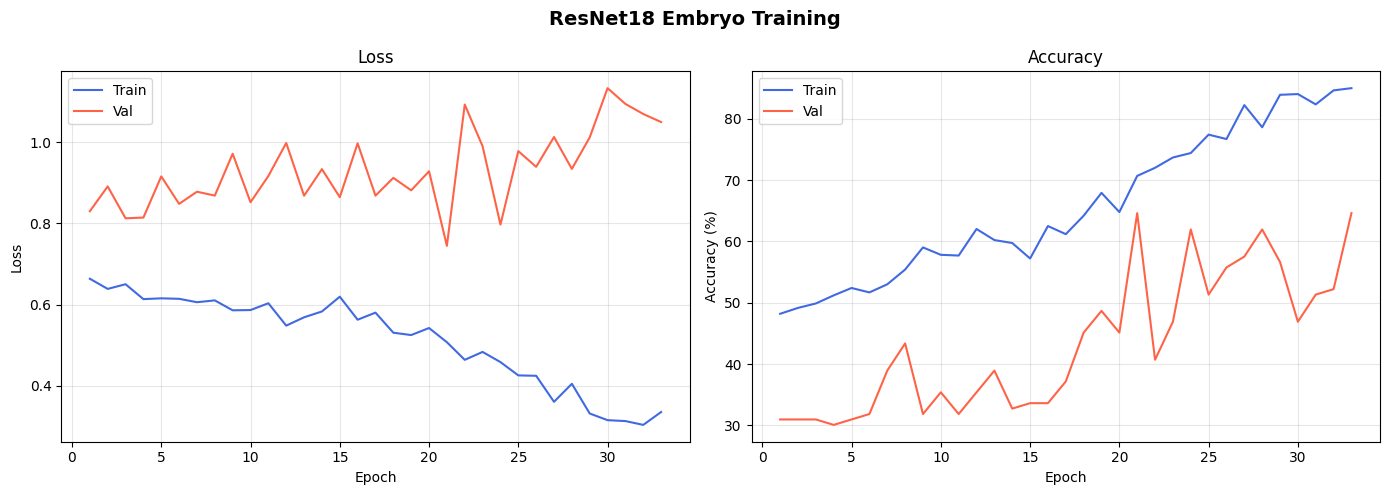

Saved training_curves.png


In [ ]:
epochs_ran = range(1, len(history['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ResNet18 Embryo Training', fontsize=14, fontweight='bold')

ax1.plot(epochs_ran, history['train_loss'], label='Train', color='royalblue')
ax1.plot(epochs_ran, history['val_loss'],   label='Val',   color='tomato')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_ran, [a*100 for a in history['train_acc']], label='Train', color='royalblue')
ax2.plot(epochs_ran, [a*100 for a in history['val_acc']],   label='Val',   color='tomato')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(LOG_DIR, 'training_curves.png'), dpi=150)
plt.show()
print('Saved training_curves.png')

## 🧪 Cell 12 — Test Set Evaluation

In [ ]:
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        probs   = torch.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())

test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f'Test Accuracy: {test_acc*100:.2f}%')
print()
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

Test Accuracy: 60.53%

              precision    recall  f1-score   support

  non_viable       0.69      0.77      0.73        26
      viable       0.33      0.25      0.29        12

    accuracy                           0.61        38
   macro avg       0.51      0.51      0.51        38
weighted avg       0.58      0.61      0.59        38



## 🔢 Cell 13 — Confusion Matrix & ROC Curve

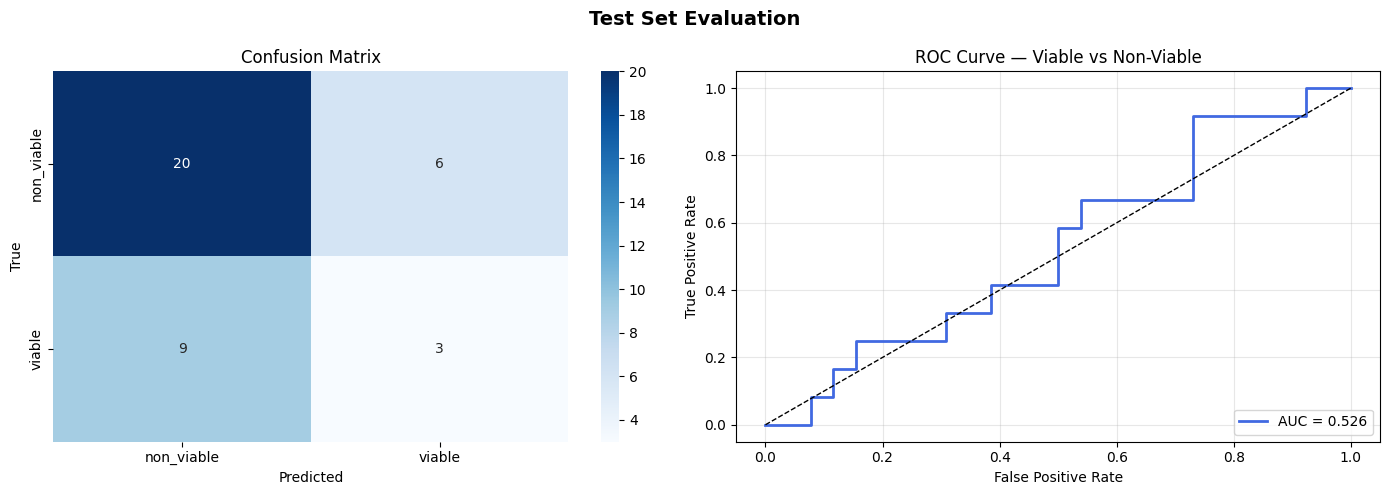

ROC AUC: 0.5256


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Test Set Evaluation', fontsize=14, fontweight='bold')

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax1)
ax1.set_title('Confusion Matrix')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('True')

viable_idx    = train_ds.class_to_idx['viable']
binary_labels = [1 if l == viable_idx else 0 for l in all_labels]
binary_probs  = [p if viable_idx == 1 else 1-p for p in all_probs]
fpr, tpr, _   = roc_curve(binary_labels, binary_probs)
roc_auc       = auc(fpr, tpr)

ax2.plot(fpr, tpr, color='royalblue', lw=2, label=f'AUC = {roc_auc:.3f}')
ax2.plot([0, 1], [0, 1], 'k--', lw=1)
ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve — Viable vs Non-Viable')
ax2.legend(loc='lower right'); ax2.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(LOG_DIR, 'evaluation_plots.png'), dpi=150)
plt.show()
print(f'ROC AUC: {roc_auc:.4f}')

## 🔍 Cell 14 — Grad-CAM Visualisation

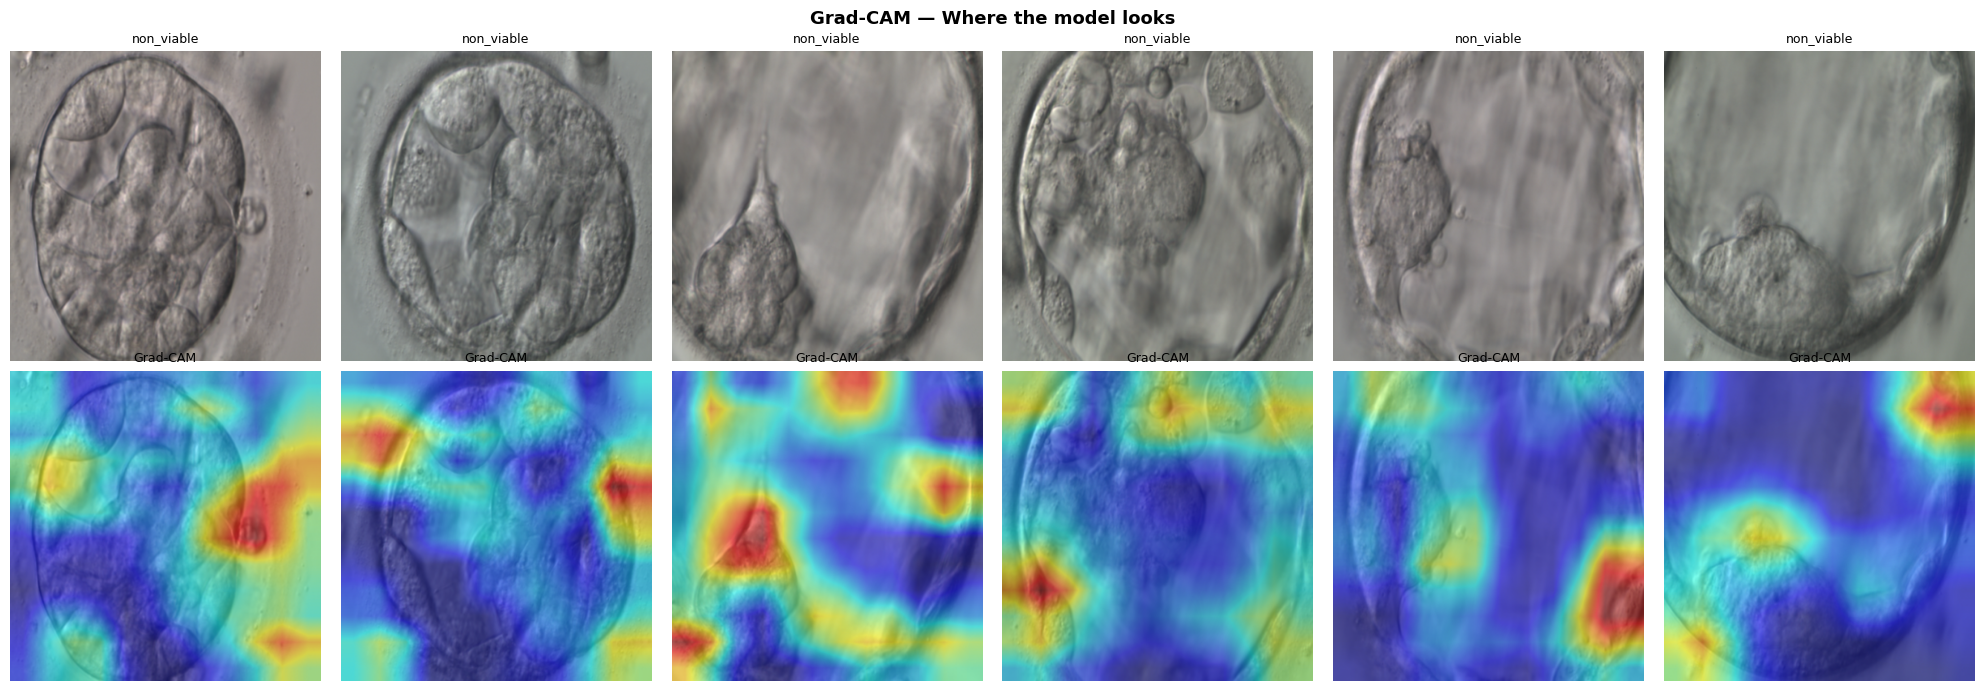

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

target_layer = model.layer4[-1]
cam = GradCAM(model=model, target_layers=[target_layer])

sample_imgs, sample_labels = next(iter(test_loader))
sample_imgs   = sample_imgs[:6]
sample_labels = sample_labels[:6]

fig, axes = plt.subplots(2, 6, figsize=(20, 7))
fig.suptitle('Grad-CAM — Where the model looks', fontsize=13, fontweight='bold')

inv_mean = np.array([0.485, 0.456, 0.406])
inv_std  = np.array([0.229, 0.224, 0.225])

for i in range(6):
    img_tensor = sample_imgs[i].unsqueeze(0).to(DEVICE)
    label_idx  = sample_labels[i].item()
    gcam       = cam(input_tensor=img_tensor,
                     targets=[ClassifierOutputTarget(label_idx)])[0]
    img_np = sample_imgs[i].numpy().transpose(1, 2, 0)
    img_np = np.clip(img_np * inv_std + inv_mean, 0, 1).astype(np.float32)
    cam_img = show_cam_on_image(img_np, gcam, use_rgb=True)
    axes[0][i].imshow(img_np)
    axes[0][i].set_title(CLASS_NAMES[label_idx], fontsize=9)
    axes[0][i].axis('off')
    axes[1][i].imshow(cam_img)
    axes[1][i].set_title('Grad-CAM', fontsize=9)
    axes[1][i].axis('off')

plt.tight_layout()
fig.savefig(os.path.join(LOG_DIR, 'gradcam.png'), dpi=150)
plt.show()

## 💾 Cell 15 — Export Model

In [ ]:
# Full checkpoint (for resuming training)
final_ckpt = os.path.join(CHECKPOINT_DIR, 'final_model.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'class_to_idx': train_ds.class_to_idx,
    'crop_size': CROP_SIZE,
    'best_val_acc': best_val_acc,
    'test_acc': test_acc,
    'history': history,
}, final_ckpt)
print(f'Checkpoint saved -> {final_ckpt}')

# TorchScript (for deployment)
model.eval()
dummy_inp = torch.randn(1, 3, CROP_SIZE, CROP_SIZE).to(DEVICE)
scripted  = torch.jit.trace(model, dummy_inp)
script_path = os.path.join(CHECKPOINT_DIR, 'model_scripted.pt')
scripted.save(script_path)
print(f'TorchScript saved -> {script_path}')

# Training log JSON
log = {
    'best_val_acc': best_val_acc,
    'test_acc': test_acc,
    'roc_auc': float(roc_auc),
    'epochs_trained': len(history['train_loss']),
    'crop_size': CROP_SIZE,
    'class_to_idx': train_ds.class_to_idx,
    'history': {k: [float(v) for v in vs] for k, vs in history.items()},
}
with open(os.path.join(LOG_DIR, 'training_log.json'), 'w') as f:
    json.dump(log, f, indent=2)

print('\nFinal Summary')
print(f'  Best Val Accuracy : {best_val_acc*100:.2f}%')
print(f'  Test Accuracy     : {test_acc*100:.2f}%')
print(f'  ROC AUC           : {roc_auc:.4f}')

Checkpoint saved -> /content/drive/MyDrive/Resnet18_fies/embryo_checkpoints/final_model.pth
TorchScript saved -> /content/drive/MyDrive/Resnet18_fies/embryo_checkpoints/model_scripted.pt

Final Summary
  Best Val Accuracy : 64.60%
  Test Accuracy     : 60.53%
  ROC AUC           : 0.5256


## 🔬 Cell 16 — Inference on New Images

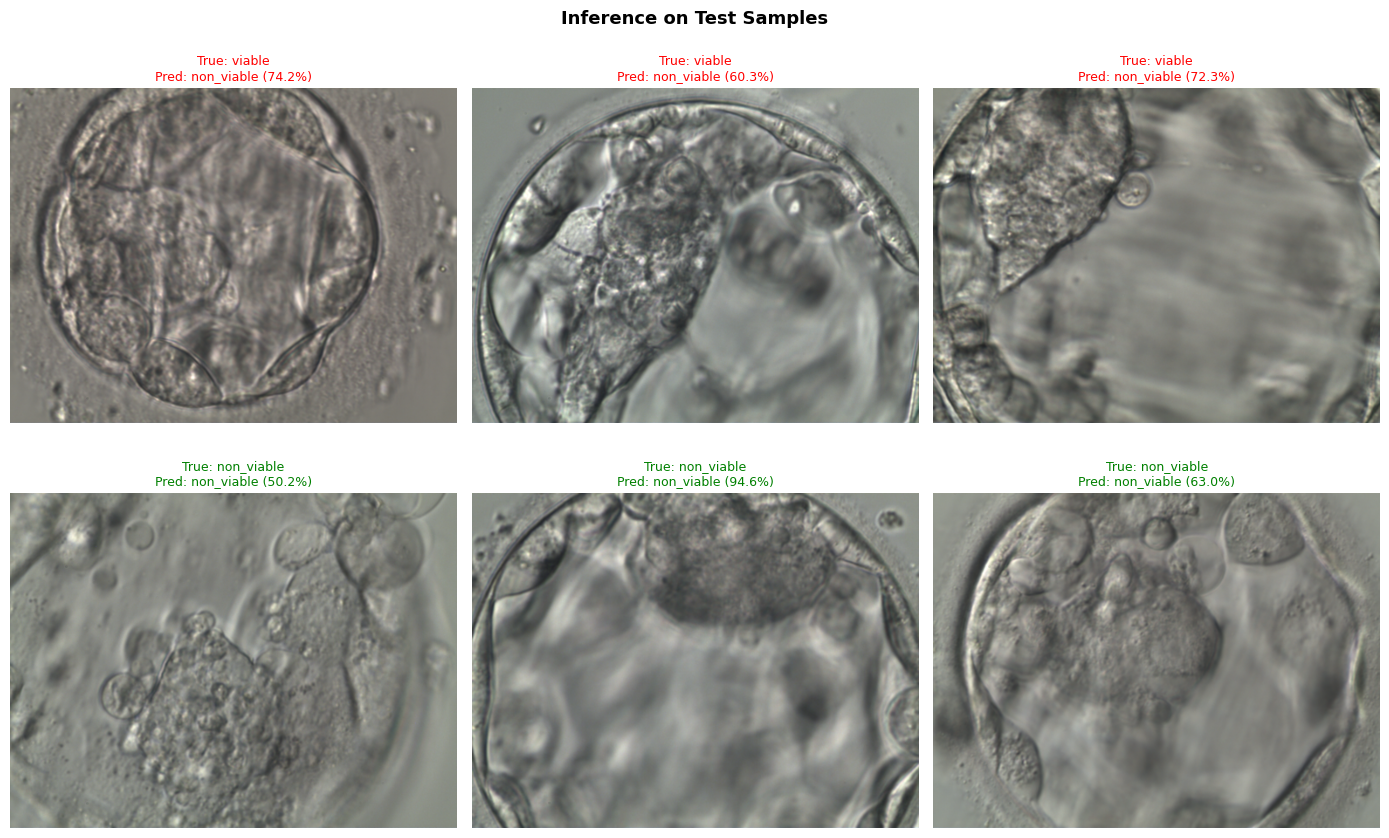

In [ ]:
def predict_image(img_path, model, class_to_idx, threshold=0.5):
    idx_to_class = {v: k for k, v in class_to_idx.items()}
    img    = Image.open(img_path).convert('RGB')
    tensor = val_test_transform(img).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1)[0]
    viable_prob = probs[class_to_idx['viable']].item()
    pred_class  = 'viable' if viable_prob >= threshold else 'non_viable'
    confidence  = viable_prob if pred_class == 'viable' else 1 - viable_prob
    return pred_class, confidence, viable_prob


test_images = (list((SPLIT_DIR / 'test' / 'viable').glob('*'))[:3] +
               list((SPLIT_DIR / 'test' / 'non_viable').glob('*'))[:3])

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()
fig.suptitle('Inference on Test Samples', fontsize=13, fontweight='bold')

for ax, img_path in zip(axes, test_images):
    pred, conf, viable_p = predict_image(img_path, model, train_ds.class_to_idx)
    true_cls = Path(img_path).parent.name
    img = Image.open(img_path).convert('RGB')
    ax.imshow(img)
    color = 'green' if pred == true_cls else 'red'
    ax.set_title(f'True: {true_cls}\nPred: {pred} ({conf*100:.1f}%)',
                 color=color, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()